# A/B Testing Case Study

## Business Problem

The product team introduced a new version of the **"Buy Now"** button on the marketplace website.

The goal of this experiment is to determine whether the new button design increases the conversion rate compared to the original version.

We will compare the conversion rates of two independent groups:

- **Control Group** – users who saw the original button.
- **Test Group** – users who saw the new button.

To evaluate the results, we will perform a statistical hypothesis test and determine whether the observed difference is statistically significant.

## Hypotheses

We will test the following hypotheses:

- **Null Hypothesis (H₀):** The conversion rates of the two groups are equal.

- **Alternative Hypothesis (H₁):** The conversion rates of the two groups are different.

The significance level is set to **α = 0.05**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of users in each group
n_control = 1000
n_test = 1000

# =================
# Conversion rates
control_rate = 0.10
test_rate = 0.12
# =================

# Simulate conversions
control = np.random.binomial(1, control_rate, n_control)
test = np.random.binomial(1, test_rate, n_test)

In [3]:
ab_data = pd.DataFrame({
    "group": ["Control"] * n_control + ["Test"] * n_test,
    "converted": np.concatenate([control, test])
})

ab_data.head()

,group,converted
0,Control,0
1,Control,1
2,Control,0
3,Control,0
4,Control,0


In [4]:
ab_data.groupby("group")["converted"].agg(
    users="count",
    conversions="sum",
    conversion_rate="mean"
)

,users,conversions,conversion_rate
group,,,
Control,1000,100,0.100
Test,1000,112,0.112


In [5]:
# Number of conversions in each group
conversions = [
    control.sum(),
    test.sum()
]

# Number of users in each group
sample_sizes = [
    n_control,
    n_test
]

# Perform Z-test
z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=sample_sizes
)

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: -0.872
P-value: 0.3834


In [6]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("The difference in conversion rates is not statistically significant.")

Fail to reject the null hypothesis.
The difference in conversion rates is not statistically significant.


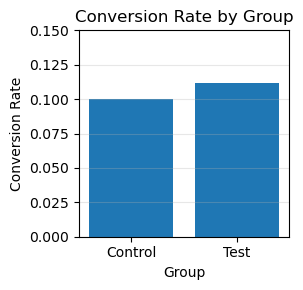

In [9]:
conversion_summary = (
    ab_data
    .groupby("group")["converted"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(3, 3))
plt.bar(
    conversion_summary["group"],
    conversion_summary["converted"]
)
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.ylim(0, 0.15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Business Interpretation

The test group achieved a higher conversion rate than the control group.

The Z-test indicates that the observed difference is statistically significant at the 5% significance level.

Therefore, the new button design is likely to improve user conversion and can be considered for deployment.